## Cellosaurus Registry — `7_cellosaurus.csv`

~152,000 entries from the community encyclopedia of all known cell lines, covering every species and category. We filter to human cancer cell lines only. The `Accession (CVCL_xxxx)` is the universal ID that ties together DepMap, HPA, and GEO naming systems. The `Identifier` column has one NaN row — always `.dropna()` before set operations.

In [1]:
import __init__ as ini
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from scipy import stats

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 100


In [2]:
df = pd.read_csv(ini.df7)

In [3]:
df.shape

(152231, 17)

In [4]:
df.head()

,Identifier (cell line name),Accession (CVCL_xxxx),Secondary accession number(s),Synonyms,Cross-references,References identifiers,Web pages,Comments,STR profile data,Diseases,Species of origin,Hierarchy,Originate from same individual,Sex of cell,Age of donor at sampling,Category,Date (entry history)
0,#132 PC3-1-SC-E8,CVCL_B0T9,NaN,Z48-5MG-70,Wikidata; Q108819335,Patent=EP0501779A1;,NaN,Group: Patented cell line. || Registration: In...,NaN,NaN,NCBI_TaxID=10090; ! Mus musculus (Mouse),CVCL_D145 ! HL-1 Friendly Myeloma-653,NaN,NaN,NaN,Hybridoma,Created: 23-09-21; Last updated: 30-01-24; Ver...
1,#132 PL12 SC-D1,CVCL_B0T8,NaN,Z48-5MG-63,Wikidata; Q108819336,Patent=EP0501779A1;,NaN,Group: Patented cell line. || Registration: In...,NaN,NaN,NCBI_TaxID=10090; ! Mus musculus (Mouse),CVCL_D145 ! HL-1 Friendly Myeloma-653,NaN,NaN,NaN,Hybridoma,Created: 23-09-21; Last updated: 30-01-24; Ver...
2,#15310-LN,CVCL_E548,NaN,15310-LN; TER461; TER-461; Ter 461; TER479; TE...,dbMHC; 48439 || ECACC; 94050311 || IHW; IHW093...,NaN,http://pathology.ucla.edu/workfiles/360cx.pdf ...,Part of: 12th International Histocompatibility...,NaN,NaN,NCBI_TaxID=9606; ! Homo sapiens (Human),NaN,NaN,Female,Age unspecified,Transformed cell line,Created: 22-10-12; Last updated: 30-01-24; Ver...
3,#16-15,CVCL_KA96,NaN,NaN,RCB; RCB4635 || Wikidata; Q54422067,PubMed=25400923;,NaN,Monoclonal antibody isotype: IgM. || Monoclona...,NaN,NaN,NCBI_TaxID=10090; ! Mus musculus (Mouse) || NC...,CVCL_4032 ! P3X63Ag8.653,NaN,NaN,NaN,Hybridoma,Created: 22-08-17; Last updated: 21-03-23; Ver...
4,#40a,CVCL_IW91,NaN,NaN,Wikidata; Q54422071,PubMed=28159921;,NaN,Characteristics: Established from parent cell ...,NaN,NCIt; C21619; Mouse mesothelioma,NCBI_TaxID=10090; ! Mus musculus (Mouse),CVCL_IW90 ! 40,NaN,Male,1-2M,Cancer cell line,Created: 15-05-17; Last updated: 29-06-23; Ver...


In [5]:
df.loc[0]

Identifier (cell line name)                                        #132 PC3-1-SC-E8
Accession (CVCL_xxxx)                                                     CVCL_B0T9
Secondary accession number(s)                                                   NaN
Synonyms                                                                 Z48-5MG-70
Cross-references                                               Wikidata; Q108819335
References identifiers                                          Patent=EP0501779A1;
Web pages                                                                       NaN
Comments                          Group: Patented cell line. || Registration: In...
STR profile data                                                                NaN
Diseases                                                                        NaN
Species of origin                          NCBI_TaxID=10090; ! Mus musculus (Mouse)
Hierarchy                                     CVCL_D145 ! HL-1 Friendly Myel

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 152231 entries, 0 to 152230
Data columns (total 17 columns):
 #   Column                          Non-Null Count   Dtype
---  ------                          --------------   -----
 0   Identifier (cell line name)     152230 non-null  str  
 1   Accession (CVCL_xxxx)           152231 non-null  str  
 2   Secondary accession number(s)   542 non-null     str  
 3   Synonyms                        72386 non-null   str  
 4   Cross-references                150430 non-null  str  
 5   References identifiers          83089 non-null   str  
 6   Web pages                       11630 non-null   str  
 7   Comments                        150484 non-null  str  
 8   STR profile data                8734 non-null    str  
 9   Diseases                        70990 non-null   str  
 10  Species of origin               152231 non-null  str  
 11  Hierarchy                       55937 non-null   str  
 12  Originate from same individual  15554 non-null   str  


### Category and species overview
Cellosaurus covers every known cell line across all species. We need to filter before any analysis — most entries are not relevant.

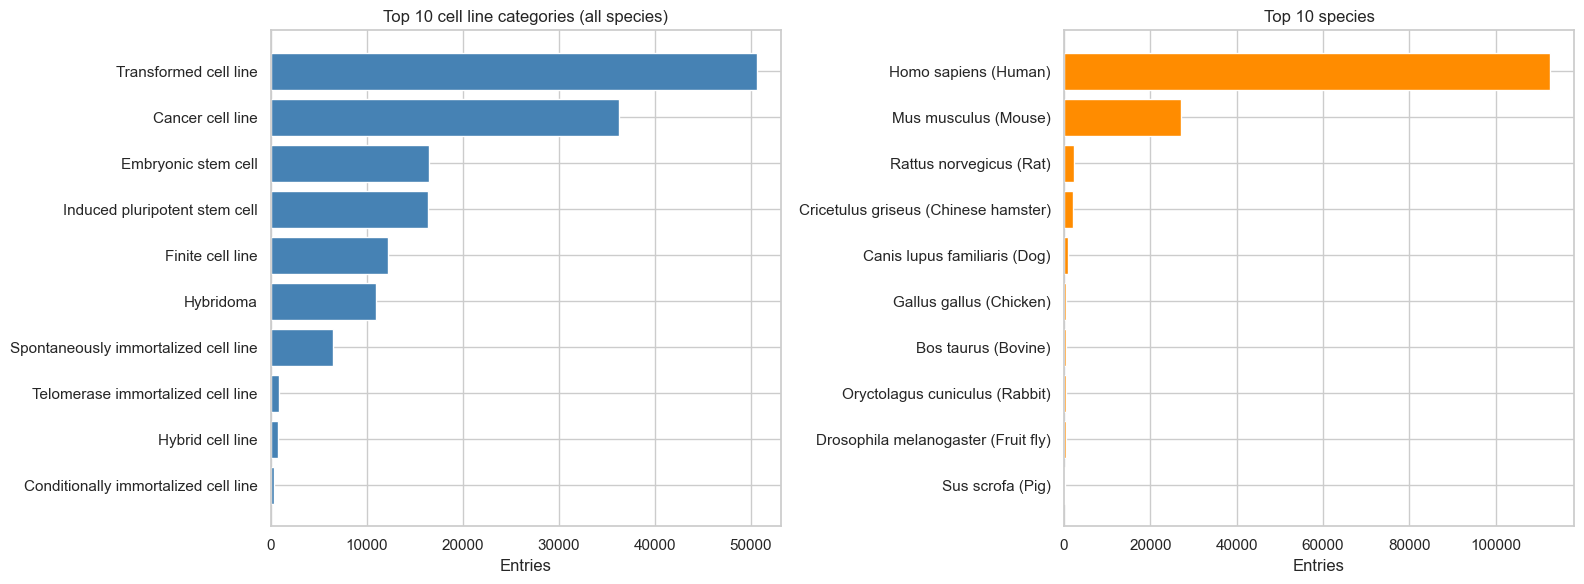

Total entries: 152231


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

top_cat = df["Category"].value_counts().head(10)
axes[0].barh(top_cat.index[::-1], top_cat.values[::-1], color="steelblue")
axes[0].set_title("Top 10 cell line categories (all species)")
axes[0].set_xlabel("Entries")

# species: extract short name from "NCBI_TaxID=9606; ! Homo sapiens (Human)"
df["species_short"] = df["Species of origin"].str.extract(r"! ([^|]+)").iloc[:, 0].str.strip()
top_sp = df["species_short"].value_counts().head(10)
axes[1].barh(top_sp.index[::-1], top_sp.values[::-1], color="darkorange")
axes[1].set_title("Top 10 species")
axes[1].set_xlabel("Entries")

plt.tight_layout(); plt.show()
print(f"Total entries: {len(df)}")


### Filter to human cancer cell lines
This is the relevant subset for our project.

In [8]:
human  = df[df["Species of origin"].str.contains(r"Homo sapiens", na=False)]
cancer = human[human["Category"] == "Cancer cell line"].copy()
print(f"All entries         : {len(df)}")
print(f"Human cell lines    : {len(human)}")
print(f"Human cancer lines  : {len(cancer)}")


All entries         : 152231
Human cell lines    : 112768
Human cancer lines  : 32242


### Disease distribution in human cancer lines
Shows which cancers dominate the database — useful for understanding coverage biases.

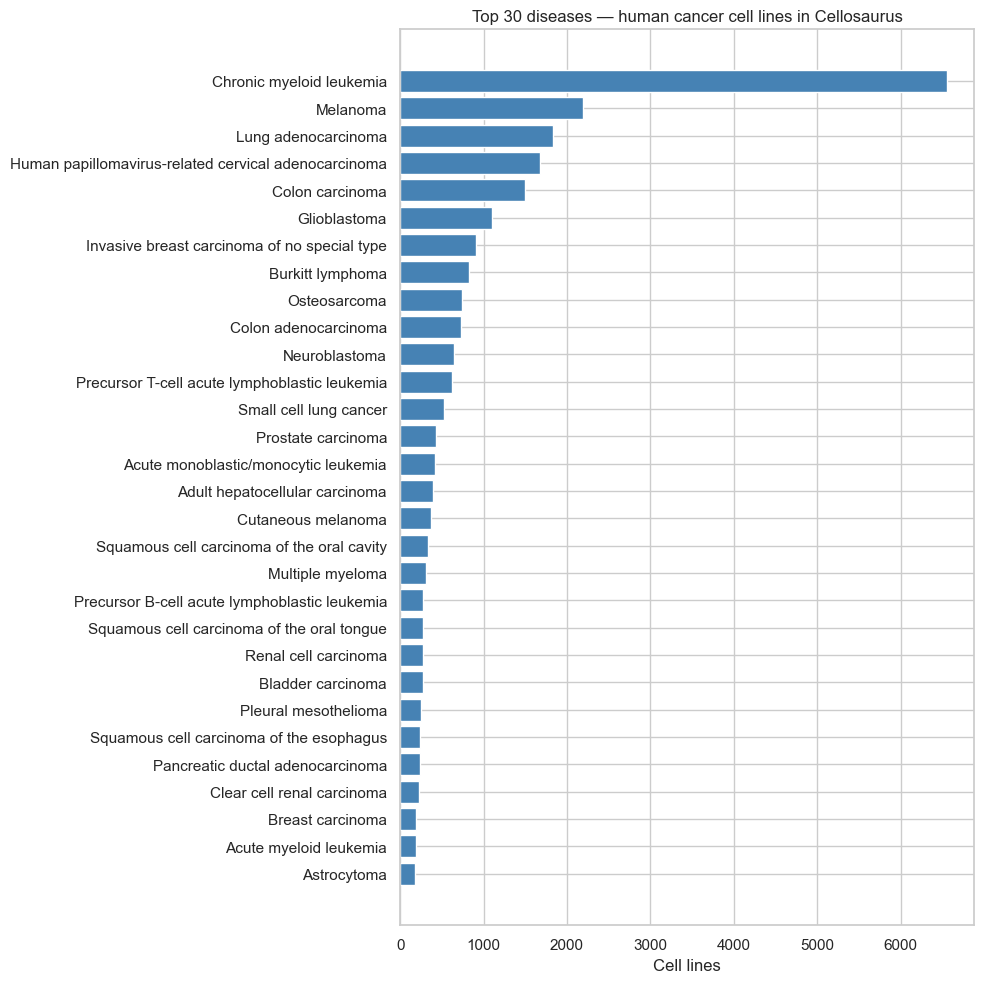

In [9]:
# parse disease: "NCIt; C3512; Lung adenocarcinoma" → "Lung adenocarcinoma"
cancer["disease_short"] = cancer["Diseases"].str.extract(r"; ([^;|]+)$").iloc[:, 0].str.strip()

fig, ax = plt.subplots(figsize=(10, 10))
top_dis = cancer["disease_short"].value_counts().head(30)
ax.barh(top_dis.index[::-1], top_dis.values[::-1], color="steelblue")
ax.set_title("Top 30 diseases — human cancer cell lines in Cellosaurus")
ax.set_xlabel("Cell lines")
plt.tight_layout(); plt.show()


### Sex distribution and synonym richness
Lines with many synonyms are prone to naming-ambiguity errors when integrating datasets.

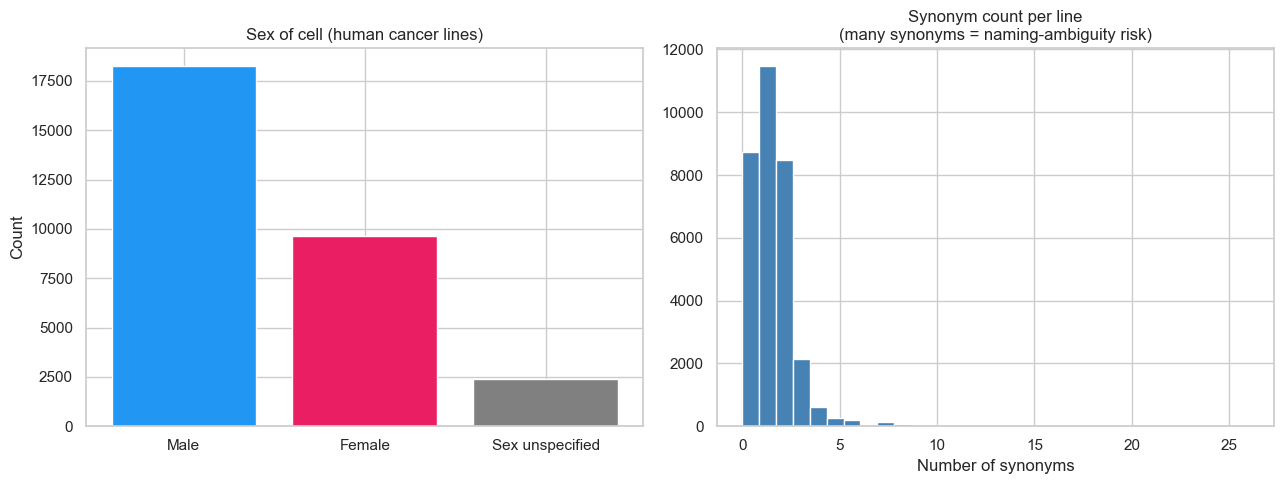

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sex = cancer["Sex of cell"].value_counts()
axes[0].bar(sex.index, sex.values, color=["#2196F3", "#E91E63", "gray"])
axes[0].set_title("Sex of cell (human cancer lines)")
axes[0].set_ylabel("Count")

# synonym count
cancer["syn_count"] = cancer["Synonyms"].fillna("").str.split(";").apply(
    lambda x: sum(1 for s in x if s.strip()))
axes[1].hist(cancer["syn_count"], bins=30, color="steelblue", edgecolor="white")
axes[1].set_title("Synonym count per line\n(many synonyms = naming-ambiguity risk)")
axes[1].set_xlabel("Number of synonyms")

plt.tight_layout(); plt.show()


### Cross-reference database coverage
Shows which lines also appear in DepMap, ATCC, DSMZ, and other resources.

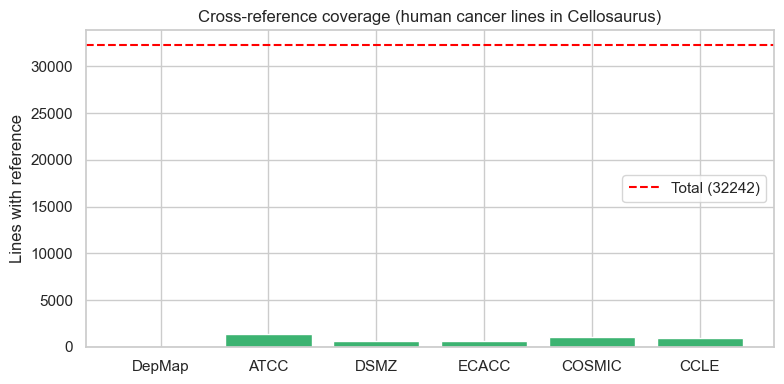

In [11]:
xref_patterns = {"DepMap": "DepMapID", "ATCC": "ATCC", "DSMZ": "DSMZ",
                 "ECACC": "ECACC", "COSMIC": "Cosmic-CLP", "CCLE": "CCLE"}
coverage = {name: cancer["Cross-references"].str.contains(pat, na=False).sum()
            for name, pat in xref_patterns.items()}

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(coverage.keys(), coverage.values(), color="mediumseagreen")
ax.axhline(len(cancer), linestyle="--", color="red", label=f"Total ({len(cancer)})")
ax.set_title("Cross-reference coverage (human cancer lines in Cellosaurus)")
ax.set_ylabel("Lines with reference")
ax.legend(); plt.tight_layout(); plt.show()


### Key findings

In [12]:
print("=== Cellosaurus ===")
print(f"Total entries              : {len(df)}")
print(f"Human cancer cell lines    : {len(cancer)}")
print(f"Unique diseases            : {cancer['disease_short'].nunique()}")
print(f"Lines with DepMap ref      : {cancer['Cross-references'].str.contains('DepMapID', na=False).sum()}")
print(f"Median synonym count       : {cancer['syn_count'].median():.0f}")


=== Cellosaurus ===
Total entries              : 152231
Human cancer cell lines    : 32242
Unique diseases            : 486
Lines with DepMap ref      : 0
Median synonym count       : 1


## Join Analysis — how this table connects to the others

df7 (Cellosaurus) is the **universal ID bridge** for non-DepMap sources.
Its `Accession (CVCL_xxxx)` equals `RRID` in df9, `Cellosaurus ID` in df11,
and `Cellosaurus_ID` in df10.

| From | Key column | To | Key column | Cardinality | Notes |
|---|---|---|---|---|---|
| df7 | `Accession` | df9 | `RRID` | 1:1 | Cellosaurus → DepMap |
| df7 | `Accession` | df11 | `Cellosaurus ID` | 1:1 | Cellosaurus → HPA meta |
| df7 | `Accession` | df10 | `Cellosaurus_ID` | 1:many | Cellosaurus → GEO |
| df11 | `Cellosaurus ID` | df7 | `Accession` | 1:1 | HPA → Cellosaurus |
| df10 | `Cellosaurus_ID` | df7 | `Accession` | many:1 | GEO → Cellosaurus |

**Biological note:** Cellosaurus has ~152k entries; DepMap only has ~1,840.
The gap represents real cell lines that exist in the world but have not been
sequenced by DepMap. These cannot be used for training but contextualise
how representative DepMap's coverage is.


In [13]:
# ── A/B: Join coverage df7 → df9, df11, df10 ────────────────────────────────
# Filter df7 to human cancer lines first (as per EDA)
human_cancer = df[
    df["Species of origin"].str.contains("Homo sapiens", na=False) &
    (df["Category"] == "Cancer cell line")
]
df7_cvcl = set(human_cancer["Accession (CVCL_xxxx)"].dropna())

df9_ids  = pd.read_csv(ini.df9,  usecols=["DepMap_ID", "RRID", "lineage"])
df11_ids = pd.read_csv(ini.df11, sep="\t", usecols=["Cell line", "Cellosaurus ID"])
df10_ids = pd.read_csv(ini.df10, sep="\t", usecols=["Geo_accession", "Cellosaurus_ID"])

df9_rrid     = set(df9_ids["RRID"].dropna())
df11_cvcl    = set(df11_ids["Cellosaurus ID"].dropna())
df10_cvcl    = set(df10_ids["Cellosaurus_ID"].dropna())

match_df9  = df7_cvcl & df9_rrid
match_df11 = df7_cvcl & df11_cvcl
match_df10 = df7_cvcl & df10_cvcl

print("=== df7 (human cancer subset) join coverage ===")
print(f"Human cancer CVCL_ entries : {len(df7_cvcl)}")
print(f"Matched in df9  (RRID)     : {len(match_df9)} ({len(match_df9)/len(df7_cvcl)*100:.1f}%)")
print(f"Matched in df11 (Cello ID) : {len(match_df11)} ({len(match_df11)/len(df7_cvcl)*100:.1f}%)")
print(f"Matched in df10 (Cello ID) : {len(match_df10)} ({len(match_df10)/len(df7_cvcl)*100:.1f}%)")
print()
print(f"Coverage overlap df9 & df11: {len(match_df9 & match_df11)}")
print(f"Coverage overlap df9 & df10: {len(match_df9 & match_df10)}")
print()
print(f"Cellosaurus human-cancer lines NOT in df9: {len(df7_cvcl - df9_rrid)}")
print(" → These are real cancer cell lines not sequenced by DepMap")


=== df7 (human cancer subset) join coverage ===
Human cancer CVCL_ entries : 32242
Matched in df9  (RRID)     : 1693 (5.3%)
Matched in df11 (Cello ID) : 1131 (3.5%)
Matched in df10 (Cello ID) : 756 (2.3%)

Coverage overlap df9 & df11: 1052
Coverage overlap df9 & df10: 576

Cellosaurus human-cancer lines NOT in df9: 30549
 → These are real cancer cell lines not sequenced by DepMap


In [14]:
# ── C: Format consistency — CVCL_ accession ─────────────────────────────────
def fmt_check(series, name, prefix=None):
    s = series.dropna().astype(str)
    print(f"Format check — {name} (n={len(s)} non-null, {series.isna().sum()} NaN):")
    print(f"  Leading whitespace  : {s.str.startswith(' ').any()}")
    print(f"  Trailing whitespace : {s.str.endswith(' ').any()}")
    if prefix:
        ok = s.str.startswith(prefix).all()
        print(f"  All start '{prefix}'  : {ok}")
        if not ok:
            print(f"  Non-prefix examples : {s[~s.str.startswith(prefix)].head(3).tolist()}")
    lens = s.str.len()
    print(f"  Length range        : {lens.min()} – {lens.max()}")
    dups = series.duplicated().sum()
    print(f"  Duplicates          : {dups}")


fmt_check(human_cancer["Accession (CVCL_xxxx)"].dropna(), "Accession df7", prefix="CVCL_")
print()
fmt_check(df9_ids["RRID"].dropna(), "RRID in df9", prefix="CVCL_")
print()
fmt_check(df11_ids["Cellosaurus ID"].dropna(), "Cellosaurus ID in df11", prefix="CVCL_")
print()
fmt_check(df10_ids["Cellosaurus_ID"].dropna(), "Cellosaurus_ID in df10", prefix="CVCL_")


Format check — Accession df7 (n=32242 non-null, 0 NaN):
  Leading whitespace  : False
  Trailing whitespace : False
  All start 'CVCL_'  : True
  Length range        : 9 – 9
  Duplicates          : 0

Format check — RRID in df9 (n=1818 non-null, 0 NaN):
  Leading whitespace  : False
  Trailing whitespace : False
  All start 'CVCL_'  : True
  Length range        : 9 – 9
  Duplicates          : 4

Format check — Cellosaurus ID in df11 (n=1198 non-null, 0 NaN):
  Leading whitespace  : False
  Trailing whitespace : False
  All start 'CVCL_'  : True
  Length range        : 9 – 9
  Duplicates          : 0

Format check — Cellosaurus_ID in df10 (n=3159 non-null, 0 NaN):
  Leading whitespace  : False
  Trailing whitespace : False
  All start 'CVCL_'  : True
  Length range        : 9 – 9
  Duplicates          : 2362


### Biological implications

The ~84–98% of DepMap cell lines (df9) that have a Cellosaurus RRID are well-covered
by the reference database. Lines without a RRID in df9 are newer or non-standard entries
that cannot be cross-referenced.

The much larger fraction of Cellosaurus entries that are NOT in DepMap represents the
"dark matter" of cancer cell lines — they exist in academic collections worldwide but
have not been profiled by DepMap. This limits CellLineSelector to lines that DepMap
has actually characterised.


In [15]:
# Biological: which diseases in Cellosaurus have the worst DepMap representation?
cello_disease = human_cancer["Diseases"].str.extract(r"; ([^;|]+)$").iloc[:,0].str.strip()
human_cancer = human_cancer.copy()
human_cancer["disease_short"] = cello_disease

in_depmap     = human_cancer[human_cancer["Accession (CVCL_xxxx)"].isin(match_df9)]
not_in_depmap = human_cancer[~human_cancer["Accession (CVCL_xxxx)"].isin(match_df9)]

total_by_dis = human_cancer["disease_short"].value_counts()
depmap_by_dis = in_depmap["disease_short"].value_counts()
pct_represented = (depmap_by_dis / total_by_dis * 100).dropna().sort_values()

print("Cancer types LEAST represented in DepMap relative to Cellosaurus (bottom 10):")
print(pct_represented.head(10).round(1).to_string())
print()
print("Cancer types BEST represented in DepMap (top 10):")
print(pct_represented.tail(10).round(1).to_string())


Cancer types LEAST represented in DepMap relative to Cellosaurus (bottom 10):
disease_short
Chronic myeloid leukemia                                             0.3
Human papillomavirus-related cervical adenocarcinoma                 0.3
Colon carcinoma                                                      0.5
Prostate carcinoma                                                   1.4
Retinoblastoma                                                       1.8
Acute monoblastic/monocytic leukemia                                 1.9
Squamous cell carcinoma of the nasal cavity and paranasal sinuses    2.2
Diffuse intrinsic pontine glioma                                     2.3
Burkitt lymphoma                                                     2.4
Invasive breast carcinoma of no special type                         2.4

Cancer types BEST represented in DepMap (top 10):
disease_short
Gastric choriocarcinoma                                                           100.0
Adult B acute lymphoblast

## Join Analysis — how this table connects to the others

df7 (Cellosaurus) is the **universal ID bridge** for non-DepMap sources.
Its `Accession (CVCL_xxxx)` equals `RRID` in df9, `Cellosaurus ID` in df11,
and `Cellosaurus_ID` in df10.

| From | Key column | To | Key column | Cardinality | Notes |
|---|---|---|---|---|---|
| df7 | `Accession` | df9 | `RRID` | 1:1 | Cellosaurus → DepMap |
| df7 | `Accession` | df11 | `Cellosaurus ID` | 1:1 | Cellosaurus → HPA meta |
| df7 | `Accession` | df10 | `Cellosaurus_ID` | 1:many | Cellosaurus → GEO |
| df11 | `Cellosaurus ID` | df7 | `Accession` | 1:1 | HPA → Cellosaurus |
| df10 | `Cellosaurus_ID` | df7 | `Accession` | many:1 | GEO → Cellosaurus |

**Biological note:** Cellosaurus has ~152k entries; DepMap only has ~1,840.
The gap represents real cell lines that exist in the world but have not been
sequenced by DepMap. These cannot be used for training but contextualise
how representative DepMap's coverage is.


In [16]:
# ── A/B: Join coverage df7 → df9, df11, df10 ────────────────────────────────
# Filter df7 to human cancer lines first (as per EDA)
human_cancer = df[
    df["Species of origin"].str.contains("Homo sapiens", na=False) &
    (df["Category"] == "Cancer cell line")
]
df7_cvcl = set(human_cancer["Accession (CVCL_xxxx)"].dropna())

df9_ids  = pd.read_csv(ini.df9,  usecols=["DepMap_ID", "RRID", "lineage"])
df11_ids = pd.read_csv(ini.df11, sep="\t", usecols=["Cell line", "Cellosaurus ID"])
df10_ids = pd.read_csv(ini.df10, sep="\t", usecols=["Geo_accession", "Cellosaurus_ID"])

df9_rrid     = set(df9_ids["RRID"].dropna())
df11_cvcl    = set(df11_ids["Cellosaurus ID"].dropna())
df10_cvcl    = set(df10_ids["Cellosaurus_ID"].dropna())

match_df9  = df7_cvcl & df9_rrid
match_df11 = df7_cvcl & df11_cvcl
match_df10 = df7_cvcl & df10_cvcl

print("=== df7 (human cancer subset) join coverage ===")
print(f"Human cancer CVCL_ entries : {len(df7_cvcl)}")
print(f"Matched in df9  (RRID)     : {len(match_df9)} ({len(match_df9)/len(df7_cvcl)*100:.1f}%)")
print(f"Matched in df11 (Cello ID) : {len(match_df11)} ({len(match_df11)/len(df7_cvcl)*100:.1f}%)")
print(f"Matched in df10 (Cello ID) : {len(match_df10)} ({len(match_df10)/len(df7_cvcl)*100:.1f}%)")
print()
print(f"Coverage overlap df9 & df11: {len(match_df9 & match_df11)}")
print(f"Coverage overlap df9 & df10: {len(match_df9 & match_df10)}")
print()
print(f"Cellosaurus human-cancer lines NOT in df9: {len(df7_cvcl - df9_rrid)}")
print(" → These are real cancer cell lines not sequenced by DepMap")


=== df7 (human cancer subset) join coverage ===
Human cancer CVCL_ entries : 32242
Matched in df9  (RRID)     : 1693 (5.3%)
Matched in df11 (Cello ID) : 1131 (3.5%)
Matched in df10 (Cello ID) : 756 (2.3%)

Coverage overlap df9 & df11: 1052
Coverage overlap df9 & df10: 576

Cellosaurus human-cancer lines NOT in df9: 30549
 → These are real cancer cell lines not sequenced by DepMap


In [17]:
# ── C: Format consistency — CVCL_ accession ─────────────────────────────────
def fmt_check(series, name, prefix=None):
    s = series.dropna().astype(str)
    print(f"Format check — {name} (n={len(s)} non-null, {series.isna().sum()} NaN):")
    print(f"  Leading whitespace  : {s.str.startswith(' ').any()}")
    print(f"  Trailing whitespace : {s.str.endswith(' ').any()}")
    if prefix:
        ok = s.str.startswith(prefix).all()
        print(f"  All start '{prefix}'  : {ok}")
        if not ok:
            print(f"  Non-prefix examples : {s[~s.str.startswith(prefix)].head(3).tolist()}")
    lens = s.str.len()
    print(f"  Length range        : {lens.min()} – {lens.max()}")
    dups = series.duplicated().sum()
    print(f"  Duplicates          : {dups}")


fmt_check(human_cancer["Accession (CVCL_xxxx)"].dropna(), "Accession df7", prefix="CVCL_")
print()
fmt_check(df9_ids["RRID"].dropna(), "RRID in df9", prefix="CVCL_")
print()
fmt_check(df11_ids["Cellosaurus ID"].dropna(), "Cellosaurus ID in df11", prefix="CVCL_")
print()
fmt_check(df10_ids["Cellosaurus_ID"].dropna(), "Cellosaurus_ID in df10", prefix="CVCL_")


Format check — Accession df7 (n=32242 non-null, 0 NaN):
  Leading whitespace  : False
  Trailing whitespace : False
  All start 'CVCL_'  : True
  Length range        : 9 – 9
  Duplicates          : 0

Format check — RRID in df9 (n=1818 non-null, 0 NaN):
  Leading whitespace  : False
  Trailing whitespace : False
  All start 'CVCL_'  : True
  Length range        : 9 – 9
  Duplicates          : 4

Format check — Cellosaurus ID in df11 (n=1198 non-null, 0 NaN):
  Leading whitespace  : False
  Trailing whitespace : False
  All start 'CVCL_'  : True
  Length range        : 9 – 9
  Duplicates          : 0

Format check — Cellosaurus_ID in df10 (n=3159 non-null, 0 NaN):
  Leading whitespace  : False
  Trailing whitespace : False
  All start 'CVCL_'  : True
  Length range        : 9 – 9
  Duplicates          : 2362


### Biological implications

The ~84–98% of DepMap cell lines (df9) that have a Cellosaurus RRID are well-covered
by the reference database. Lines without a RRID in df9 are newer or non-standard entries
that cannot be cross-referenced.

The much larger fraction of Cellosaurus entries that are NOT in DepMap represents the
"dark matter" of cancer cell lines — they exist in academic collections worldwide but
have not been profiled by DepMap. This limits CellLineSelector to lines that DepMap
has actually characterised.


In [18]:
# Biological: which diseases in Cellosaurus have the worst DepMap representation?
cello_disease = human_cancer["Diseases"].str.extract(r"; ([^;|]+)$").iloc[:,0].str.strip()
human_cancer = human_cancer.copy()
human_cancer["disease_short"] = cello_disease

in_depmap     = human_cancer[human_cancer["Accession (CVCL_xxxx)"].isin(match_df9)]
not_in_depmap = human_cancer[~human_cancer["Accession (CVCL_xxxx)"].isin(match_df9)]

total_by_dis = human_cancer["disease_short"].value_counts()
depmap_by_dis = in_depmap["disease_short"].value_counts()
pct_represented = (depmap_by_dis / total_by_dis * 100).dropna().sort_values()

print("Cancer types LEAST represented in DepMap relative to Cellosaurus (bottom 10):")
print(pct_represented.head(10).round(1).to_string())
print()
print("Cancer types BEST represented in DepMap (top 10):")
print(pct_represented.tail(10).round(1).to_string())


Cancer types LEAST represented in DepMap relative to Cellosaurus (bottom 10):
disease_short
Chronic myeloid leukemia                                             0.3
Human papillomavirus-related cervical adenocarcinoma                 0.3
Colon carcinoma                                                      0.5
Prostate carcinoma                                                   1.4
Retinoblastoma                                                       1.8
Acute monoblastic/monocytic leukemia                                 1.9
Squamous cell carcinoma of the nasal cavity and paranasal sinuses    2.2
Diffuse intrinsic pontine glioma                                     2.3
Burkitt lymphoma                                                     2.4
Invasive breast carcinoma of no special type                         2.4

Cancer types BEST represented in DepMap (top 10):
disease_short
Gastric choriocarcinoma                                                           100.0
Adult B acute lymphoblast

## Deeper dive: cell-line QC - contaminated / misidentified lines

A real hazard in cancer research is using a **misidentified or contaminated** cell line.
Cellosaurus records this in free-text `Comments` (and `Problematic cell line` flags).
Surfacing these lets the pipeline exclude or down-weight untrustworthy lines - a concrete
part of the "why this cell line" justification.

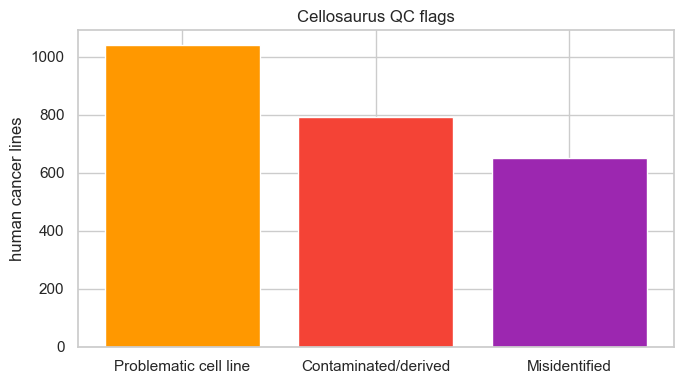

{'Problematic cell line': 1039, 'Contaminated/derived': 791, 'Misidentified': 651} of 32242 human cancer lines

Examples flagged 'Problematic':
   Identifier (cell line name) Accession (CVCL_xxxx)
                        1-5c-4             CVCL_2260
                        1181N1             CVCL_D317
                        1205Lu             CVCL_5239
                        1321N1             CVCL_0110
1321N1 (+Galpha16) AequoScreen             CVCL_5I82


In [19]:
com = cancer["Comments"].fillna("")
flags = {
    "Problematic cell line": com.str.contains("Problematic", case=False).sum(),
    "Contaminated/derived" : com.str.contains("ontaminat", case=False).sum(),
    "Misidentified"        : com.str.contains("isidentif", case=False).sum(),
}
fig, ax = plt.subplots(figsize=(7,4))
ax.bar(flags.keys(), flags.values(), color=["#FF9800","#F44336","#9C27B0"])
ax.set_ylabel("human cancer lines"); ax.set_title("Cellosaurus QC flags")
plt.tight_layout(); plt.show()
print({k: int(v) for k,v in flags.items()}, "of", len(cancer), "human cancer lines")
print("\nExamples flagged 'Problematic':")
ex = cancer[com.str.contains("Problematic", case=False)][["Identifier (cell line name)","Accession (CVCL_xxxx)"]].head(5)
print(ex.to_string(index=False))

## In Plain English — What This Dataset Means & Where It Goes Next

### 1. What this data actually is (layman terms)
This is the **global phone book of cell lines** — **Cellosaurus**, a registry of **152,000+ known cell lines** across every species and category. Its job isn't to measure biology; it's to be the **official dictionary of names**. Every cell line has a permanent ID (`Accession`, like `CVCL_xxxx`) plus all its nicknames, so that when two datasets call the same cell line by different names, we can prove they're the same thing.

### 2. What we found, and the next steps (preprocessing + missing EDA)
What the notebook showed:
- **152,231 total entries**; filtering to human cancer lines leaves **~32,242**.
- The `Accession` (`CVCL_`) code is the **universal translator** that other files (df9, df10, df11) bridge through.
- A sobering fact: only a small fraction of those 32k human cancer lines actually have measured omics data — i.e., **~94% of the world's catalogued cancer cell lines are "untrainable"** because nobody has measured them.

Next steps (preprocessing):
- **Filter to human cancer lines** for this project.
- **Use `Accession (CVCL_)` as the bridge key** wherever name-translation is needed.
- It is **not a feature source** — keep it purely as the join/translation backbone.

Still missing in EDA: nothing major — its role is well understood. Worth **documenting the ~94% untrainable share** so everyone understands the universe of cell lines we *can't* model.

### 3. Which ML approach fits this dataset
**Neither — this is not a model input.** Cellosaurus is a **reference / ID-mapping table**: it's the dictionary that lets every other dataset agree on which cell line is which. No supervised or unsupervised learning runs on it; it silently powers the joins that make the rest of the modeling possible.

> **Big-picture note:** Without this dictionary, the differently-named datasets couldn't be lined up onto the DepMap spine at all — so it's foundational infrastructure, not a feature.